# Module 3 — Line Trace
**Topics:** Load line image · Extract pixel path · Convert to world coords · Drive whole bot · Plot actual vs desired

The full robot (base + arm) drives along a path extracted from `assets/maps/line_path_01.png`.

## 0. Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import cv2
import pybullet as p

from env.pybullet_env  import PyBulletEnv
from env.robot_loader  import RobotLoader
from utils.controllers import OmniDriveController, BasePoseController, ArmController
from utils.visualizer  import DebugVisualizer

PATH_IMG = os.path.join('..','assets','maps','line_path_01.png')
print('Imports OK')

Imports OK


pybullet build time: Oct 21 2025 17:40:50


## 1. Load and inspect line image

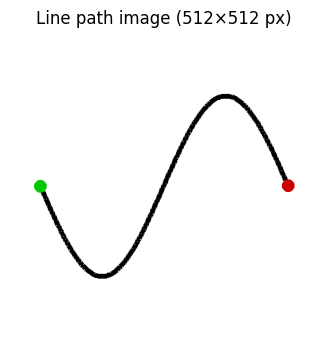

Image size: 512 x 512


In [2]:
img = cv2.imread(PATH_IMG)
assert img is not None, f'Image not found: {PATH_IMG}'
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
H, W    = img.shape[:2]

plt.figure(figsize=(6,4))
plt.imshow(img_rgb)
plt.title(f'Line path image ({W}×{H} px)'); plt.axis('off'); plt.show()
print(f'Image size: {W} x {H}')

## 2. Extract line path from image

In [3]:
def extract_path(img_bgr, num_points=80):
    """
    Extract ordered path waypoints from a black line on white background.
    Returns array of (col, row) pixel coordinates.
    """
    gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, bw = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY_INV)

    # Skeletonise using morphological thinning
    kernel   = np.ones((3,3), np.uint8)
    skeleton = np.zeros_like(bw)
    temp     = bw.copy()
    for _ in range(50):
        eroded  = cv2.erode(temp, kernel)
        opened  = cv2.dilate(eroded, kernel)
        subset  = cv2.subtract(temp, opened)
        skeleton= cv2.bitwise_or(skeleton, subset)
        temp    = eroded
        if cv2.countNonZero(temp) == 0:
            break

    # Get all non-zero pixels and sort by x
    pts = np.column_stack(np.where(skeleton > 0))  # (row, col)
    if len(pts) == 0:
        # Fallback: use raw binary pixels
        pts = np.column_stack(np.where(bw > 0))
    pts = pts[:, [1, 0]]   # → (col, row)
    pts = pts[pts[:,0].argsort()]

    # Subsample evenly
    idx = np.linspace(0, len(pts)-1, num_points, dtype=int)
    return pts[idx].astype(float)

px_path = extract_path(img, num_points=60)
print(f'Extracted {len(px_path)} waypoints')
print(f'Pixel range X: [{px_path[:,0].min():.0f}, {px_path[:,0].max():.0f}]  '
      f'Y: [{px_path[:,1].min():.0f}, {px_path[:,1].max():.0f}]')

Extracted 60 waypoints
Pixel range X: [43, 469]  Y: [109, 406]


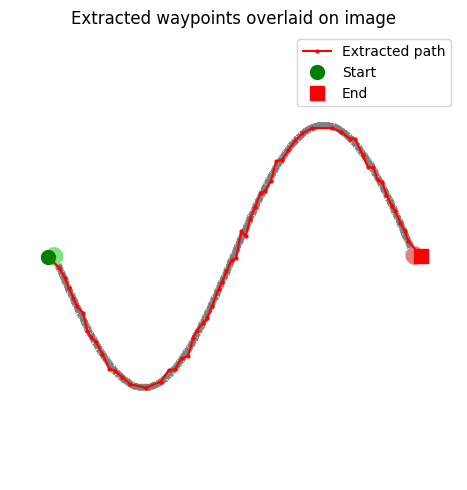

In [4]:
plt.figure(figsize=(7,5))
plt.imshow(img_rgb, alpha=0.5)
plt.plot(px_path[:,0], px_path[:,1], 'r.-', ms=4, lw=1.5, label='Extracted path')
plt.plot(px_path[0,0],  px_path[0,1],  'go', ms=10, label='Start')
plt.plot(px_path[-1,0], px_path[-1,1], 'rs', ms=10, label='End')
plt.legend(); plt.title('Extracted waypoints overlaid on image'); plt.axis('off')
plt.tight_layout(); plt.show()

## 3. Convert pixel path → world coordinates

In [5]:
# Map image pixels to world metres
# Image is W×H pixels representing WORLD_W × WORLD_H metres
WORLD_W = 2.0   # reduced from 4.0 — path fits within 2m arena
WORLD_H = 1.5   # reduced from 3.0

def px_to_world(px_xy, img_w, img_h, world_w, world_h):
    wx = (px_xy[:,0] / img_w) * world_w - world_w / 2
    wy = -(px_xy[:,1] / img_h) * world_h + world_h / 2
    return np.stack([wx, wy], axis=1)

world_path = px_to_world(px_path, W, H, WORLD_W, WORLD_H)

# Shift path so it starts at robot origin [0,0]
world_path -= world_path[0]   # translate start to (0,0)

print(f'World X: [{world_path[:,0].min():.2f}, {world_path[:,0].max():.2f}] m')
print(f'World Y: [{world_path[:,1].min():.2f}, {world_path[:,1].max():.2f}] m')
print(f'Path start: {world_path[0]}  (should be [0, 0])')
print(f'Path length: {np.sum(np.linalg.norm(np.diff(world_path, axis=0), axis=1)):.2f} m')

World X: [0.00, 1.66] m
World Y: [-0.44, 0.43] m
Path start: [0. 0.]  (should be [0, 0])
Path length: 2.60 m


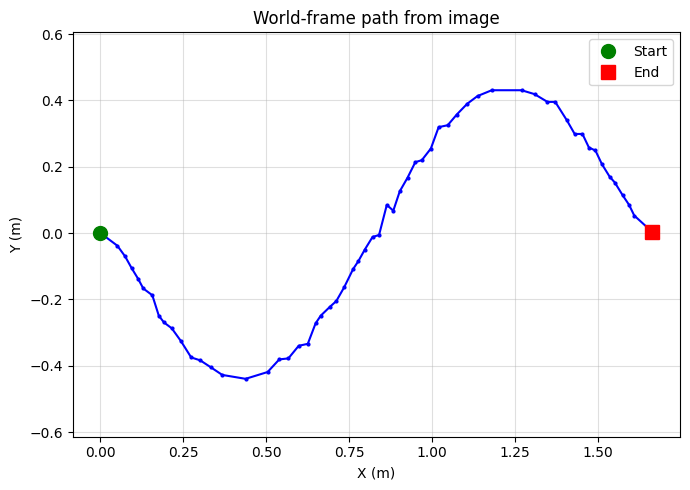

In [6]:
plt.figure(figsize=(7,5))
plt.plot(world_path[:,0], world_path[:,1], 'b.-', ms=4, lw=1.5)
plt.plot(world_path[0,0],  world_path[0,1],  'go', ms=10, label='Start')
plt.plot(world_path[-1,0], world_path[-1,1], 'rs', ms=10, label='End')
plt.xlabel('X (m)'); plt.ylabel('Y (m)')
plt.title('World-frame path from image')
plt.axis('equal'); plt.grid(alpha=0.4); plt.legend()
plt.tight_layout(); plt.show()

## 4. Start simulation & load robot

In [7]:
env    = PyBulletEnv(gui=True)
env.start()
loader = RobotLoader()
loader.load()
omni   = OmniDriveController(loader)
ctrl   = BasePoseController(omni, max_lin=0.35, goal_tol=0.08)
arm    = ArmController(loader)
viz    = DebugVisualizer()

# Fold arm out of the way
arm.move_to(np.array([0.0, -0.5, 0.8]), env=env, steps=100)
env.step_n(40)

# Draw desired path in simulation
viz.draw_path(world_path, color=(0.,0.8,0.2))
viz.draw_waypoints(world_path[::8])
viz.label('START', world_path[0].tolist()+[0.2], color=(0,1,0))
viz.label('END',   world_path[-1].tolist()+[0.2], color=(1,0,0))

print('Environment ready. Path drawn in PyBullet.')

Environment ready. Path drawn in PyBullet.


## 5. Drive along the path & record actual trajectory

In [8]:
# Fold arm before driving
arm.move_to(np.array([0.0, -0.8, 1.4]), env=env, steps=150)
env.step_n(50)
print('Arm folded')

Arm folded


In [9]:
from utils.path_planning import PurePursuitTracker

tracker = PurePursuitTracker(
    [w.astype(float) for w in world_path],
    look_ahead=0.08,    # reduced from 0.30 — tighter corner tracking
    max_lin=0.20,       # reduced from 0.35 — slower = more accurate
    goal_tol=0.06,
)
actual    = []
max_steps = 18000       # increased for slower speed
step      = 0

print('Following path ...')
while not tracker.done and step < max_steps:
    pos, orn = loader.get_base_pose()
    yaw = float(np.arctan2(
        2*(orn[3]*orn[2] + orn[0]*orn[1]),
        1 - 2*(orn[1]**2 + orn[2]**2)))
    vx, vy, wz = tracker.step(pos[:2], yaw)
    omni.cmd_vel_world(vx, vy, wz)
    env.step()
    actual.append(pos[:2].copy())
    step += 1
    if step % 2000 == 0:
        print(f'  step {step} / {max_steps}')

omni.stop()
actual = np.array(actual)
print(f'Finished in {step} steps. {"✓" if tracker.done else "(timeout)"}')

Following path ...
  step 2000 / 18000
  step 4000 / 18000
  step 6000 / 18000
Finished in 6345 steps. ✓


## 6. Plot desired vs actual trajectory

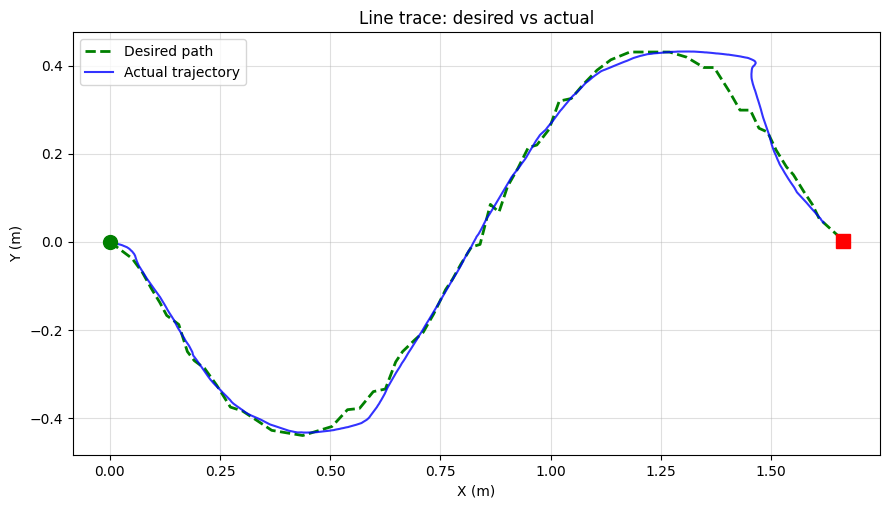

In [10]:
fig, ax = plt.subplots(figsize=(9,6))
ax.plot(world_path[:,0], world_path[:,1], 'g--', lw=2, label='Desired path')
ax.plot(actual[:,0],     actual[:,1],     'b-',  lw=1.5, alpha=0.8, label='Actual trajectory')
ax.plot(world_path[0,0],  world_path[0,1],  'go', ms=10)
ax.plot(world_path[-1,0], world_path[-1,1], 'rs', ms=10)
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_title('Line trace: desired vs actual')
ax.set_aspect('equal'); ax.grid(alpha=0.4); ax.legend()
plt.tight_layout(); plt.show()

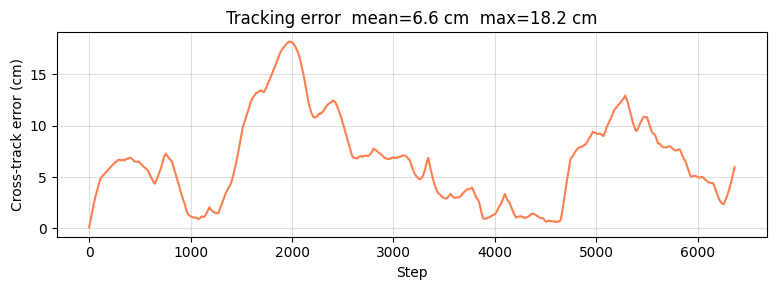

Mean error: 6.6 cm
Max  error: 18.2 cm


In [11]:
# Cross-track error at each waypoint
from scipy.interpolate import interp1d

if len(actual) > 2:
    # Resample desired path to same number of points as actual
    t_des = np.linspace(0,1,len(world_path))
    t_act = np.linspace(0,1,len(actual))
    fx = interp1d(t_des, world_path[:,0], kind='linear', fill_value='extrapolate')
    fy = interp1d(t_des, world_path[:,1], kind='linear', fill_value='extrapolate')
    des_resampled = np.stack([fx(t_act), fy(t_act)], axis=1)
    cross_err = np.linalg.norm(actual - des_resampled, axis=1)

    plt.figure(figsize=(8,3))
    plt.plot(cross_err*100, color='coral', lw=1.5)
    plt.xlabel('Step'); plt.ylabel('Cross-track error (cm)')
    plt.title(f'Tracking error  mean={cross_err.mean()*100:.1f} cm  max={cross_err.max()*100:.1f} cm')
    plt.grid(alpha=0.4); plt.tight_layout(); plt.show()
    print(f'Mean error: {cross_err.mean()*100:.1f} cm')
    print(f'Max  error: {cross_err.max()*100:.1f} cm')

## 7. Cleanup

In [12]:
viz.clear(); env.close()
print('Done.')

Done.
